In [1]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

# Function to select file using Tkinter
def select_file():
    root = tk.Tk()
    root.withdraw()  # Hide the root window
    file_path = filedialog.askopenfilename(title="Select GITT Data File",
                                           filetypes=[("Excel files", "*.xlsx"), ("CSV files", "*.csv")])
    return file_path

# Load GITT Data
file_path = select_file()
if not file_path:
    print("No file selected. Exiting...")
    exit()

# Determine file type and read the data
if file_path.endswith(".xlsx"):
    df = pd.read_excel(file_path)
elif file_path.endswith(".csv"):
    df = pd.read_csv(file_path)
else:
    print("Unsupported file format. Please select an Excel or CSV file.")
    exit()

# Convert time from hours to seconds
df["time/s"] = df["time/h"] * 3600




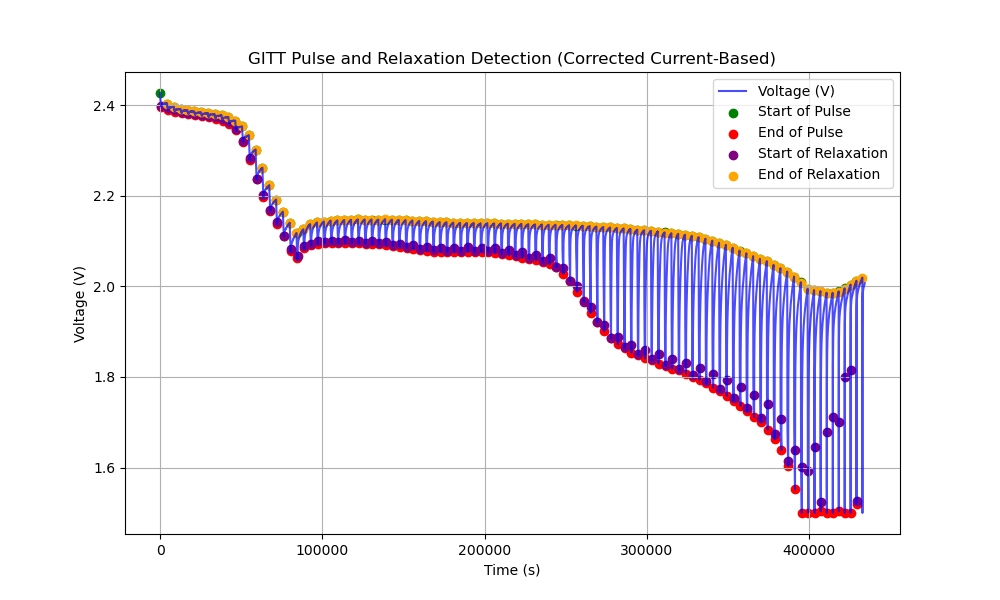

Detection results saved to GITT_corrected_current_based_pulse_detection.xlsx
Number of detected pulses: 104
Pulse Start Indices: [2, 213, 423, 634, 844, 1055, 1265, 1476, 1686, 1897, 2107, 2318, 2528, 2739, 2949, 3160, 3370, 3581, 3791, 4002, 4212, 4423, 4633, 4844, 5054, 5265, 5475, 5686, 5896, 6107, 6317, 6528, 6738, 6949, 7159, 7370, 7580, 7791, 8001, 8212, 8422, 8633, 8843, 9054, 9264, 9475, 9685, 9896, 10106, 10317, 10527, 10738, 10948, 11159, 11369, 11580, 11790, 12001, 12211, 12422, 12632, 12843, 13053, 13264, 13474, 13685, 13895, 14106, 14316, 14527, 14737, 14948, 15158, 15369, 15579, 15790, 16000, 16211, 16421, 16632, 16842, 17053, 17263, 17474, 17684, 17895, 18105, 18316, 18526, 18737, 18947, 19158, 19368, 19579, 19789, 19999, 20198, 20394, 20586, 20774, 20960, 21144, 21328, 21511]
Pulse End Indices: [32, 243, 453, 664, 874, 1085, 1295, 1506, 1716, 1927, 2137, 2348, 2558, 2769, 2979, 3190, 3400, 3611, 3821, 4032, 4242, 4453, 4663, 4874, 5084, 5295, 5505, 5716, 5926, 6137, 634

In [2]:
# Step 3: Convert Current to Amperes (if needed)
df["Current/A"] = df["<I>/mA"] / 1000  # Convert mA to A

# Step 4: Detect Key Points Using Current Transitions
pulse_starts = df.index[(df["Current/A"].shift(0) == 0) & (df["Current/A"].shift(-1) < 0)].tolist()
pulse_ends = df.index[(df["Current/A"].shift(0) < 0) & (df["Current/A"].shift(-1) == 0)].tolist()

# Step 5: Detect Start of Relaxation (First Zero-Current Point After Pulse)
relax_starts = [i + 1 for i in pulse_ends if i + 1 < len(df)]

# Step 6: Detect End of Relaxation (Last Zero-Current Point Before Next Pulse)
relax_ends = []
for start in pulse_starts[1:]:  # Ignore the first pulse for this
    relax_end_candidates = df.index[(df.index < start) & (df["Current/A"] == 0)].tolist()
    if relax_end_candidates:
        relax_ends.append(relax_end_candidates[-1])  # Take the last zero-current before the pulse

# Ensure all lists have the same length
min_length = min(len(pulse_starts), len(pulse_ends), len(relax_starts), len(relax_ends))
pulse_starts = pulse_starts[:min_length]
pulse_ends = pulse_ends[:min_length]
relax_starts = relax_starts[:min_length]
relax_ends = relax_ends[:min_length]

# Step 7: Create a DataFrame for Detected Points
detection_results = pd.DataFrame({
    "Pulse Start Time (s)": df.iloc[pulse_starts]["time/s"].values,
    "Pulse End Time (s)": df.iloc[pulse_ends]["time/s"].values,
    "Relaxation Start Time (s)": df.iloc[relax_starts]["time/s"].values,
    "Relaxation End Time (s)": df.iloc[relax_ends]["time/s"].values,
    "Pulse Start Voltage (V)": df.iloc[pulse_starts]["Ewe/V"].values,
    "Pulse End Voltage (V)": df.iloc[pulse_ends]["Ewe/V"].values,
    "Relaxation Start Voltage (V)": df.iloc[relax_starts]["Ewe/V"].values,
    "Relaxation End Voltage (V)": df.iloc[relax_ends]["Ewe/V"].values,
    "Capacity_ends (mAh/g)": df.iloc[pulse_ends]["Capacity/mA.h/g"].values,
    "Capacity_starts (mAh/g)": df.iloc[pulse_starts]["Capacity/mA.h/g"].values,
})

# Step 8: Plot Voltage with Detected Points
plt.figure(figsize=(10, 6))
plt.plot(df["time/s"], df["Ewe/V"], label="Voltage (V)", color='b', alpha=0.7)

# Highlight detected points
plt.scatter(df.iloc[pulse_starts]["time/s"], df.iloc[pulse_starts]["Ewe/V"], 
            color='g', marker='o', label="Start of Pulse")
plt.scatter(df.iloc[pulse_ends]["time/s"], df.iloc[pulse_ends]["Ewe/V"], 
            color='r', marker='o', label="End of Pulse")
plt.scatter(df.iloc[relax_starts]["time/s"], df.iloc[relax_starts]["Ewe/V"], 
            color='purple', marker='o', label="Start of Relaxation")
plt.scatter(df.iloc[relax_ends]["time/s"], df.iloc[relax_ends]["Ewe/V"], 
            color='orange', marker='o', label="End of Relaxation")

# Labels and title
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("GITT Pulse and Relaxation Detection (Corrected Current-Based)")
plt.legend()
plt.grid(True)
plt.show()

# Step 9: Save Results to Excel
output_file = "GITT_corrected_current_based_pulse_detection.xlsx"
detection_results.to_excel(output_file, index=False)
print(f"Detection results saved to {output_file}")

# Step 10: Print Summary
print(f"Number of detected pulses: {len(pulse_starts)}")
print(f"Pulse Start Indices: {pulse_starts}")
print(f"Pulse End Indices: {pulse_ends}")
print(f"Relaxation Start Indices: {relax_starts}")
print(f"Relaxation End Indices: {relax_ends}")

In [3]:
# ΔE_relax = Potential at Relaxation End - Potential at Relaxation Start
detection_results["ΔE_relax (V)"] = (
    detection_results["Relaxation End Voltage (V)"] - detection_results["Relaxation Start Voltage (V)"]
)

# Compute Pulse Start Next Voltage (Shift the start of pulse index forward by one step)
pulse_start_next_index = [i + 1 for i in detection_results.index if i + 1 < len(detection_results)]
detection_results.loc[detection_results.index[:-1], "Pulse Start Next Voltage (V)"] = detection_results.loc[
    pulse_start_next_index, "Pulse Start Voltage (V)"].values

# Compute ΔE using Pulse End and the corrected Pulse Start Next Voltage
detection_results["ΔE_corrected (V)"] = (
    detection_results["Pulse End Voltage (V)"] - detection_results["Pulse Start Next Voltage (V)"]
)



# 📌 Step 8: Save and Display Updated Data
output_file = "GITT_final_corrected_voltage_steps.xlsx"
detection_results.to_excel(output_file, index=False)
print(f"Final IR-corrected voltage steps saved to {output_file}")

# 📌 Step 9: Print Summary
print(f"Number of detected pulses: {len(pulse_starts)}")
print(f"Pulse Start Indices: {pulse_starts}")
print(f"Pulse End Indices: {pulse_ends}")
print(f"Relaxation Start Indices: {relax_starts}")
print(f"Relaxation End Indices: {relax_ends}")

Final IR-corrected voltage steps saved to GITT_final_corrected_voltage_steps.xlsx
Number of detected pulses: 104
Pulse Start Indices: [2, 213, 423, 634, 844, 1055, 1265, 1476, 1686, 1897, 2107, 2318, 2528, 2739, 2949, 3160, 3370, 3581, 3791, 4002, 4212, 4423, 4633, 4844, 5054, 5265, 5475, 5686, 5896, 6107, 6317, 6528, 6738, 6949, 7159, 7370, 7580, 7791, 8001, 8212, 8422, 8633, 8843, 9054, 9264, 9475, 9685, 9896, 10106, 10317, 10527, 10738, 10948, 11159, 11369, 11580, 11790, 12001, 12211, 12422, 12632, 12843, 13053, 13264, 13474, 13685, 13895, 14106, 14316, 14527, 14737, 14948, 15158, 15369, 15579, 15790, 16000, 16211, 16421, 16632, 16842, 17053, 17263, 17474, 17684, 17895, 18105, 18316, 18526, 18737, 18947, 19158, 19368, 19579, 19789, 19999, 20198, 20394, 20586, 20774, 20960, 21144, 21328, 21511]
Pulse End Indices: [32, 243, 453, 664, 874, 1085, 1295, 1506, 1716, 1927, 2137, 2348, 2558, 2769, 2979, 3190, 3400, 3611, 3821, 4032, 4242, 4453, 4663, 4874, 5084, 5295, 5505, 5716, 5926, 6137

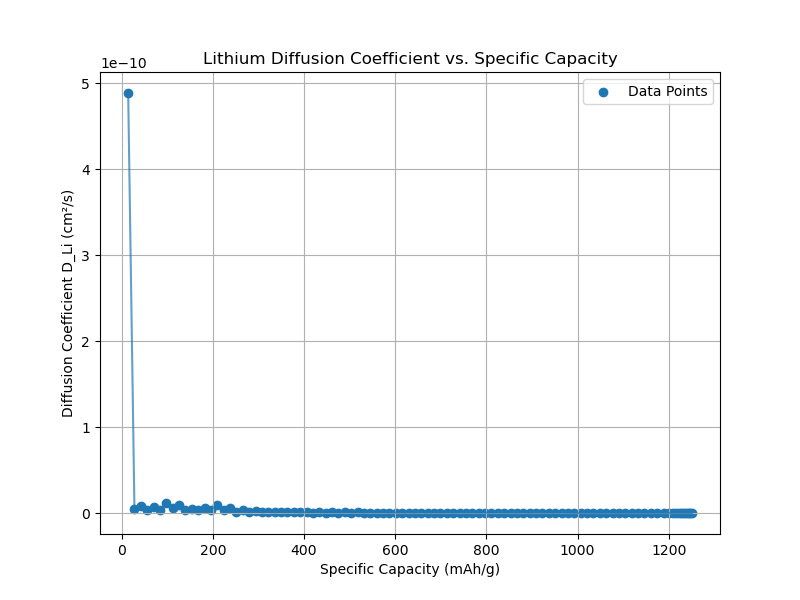

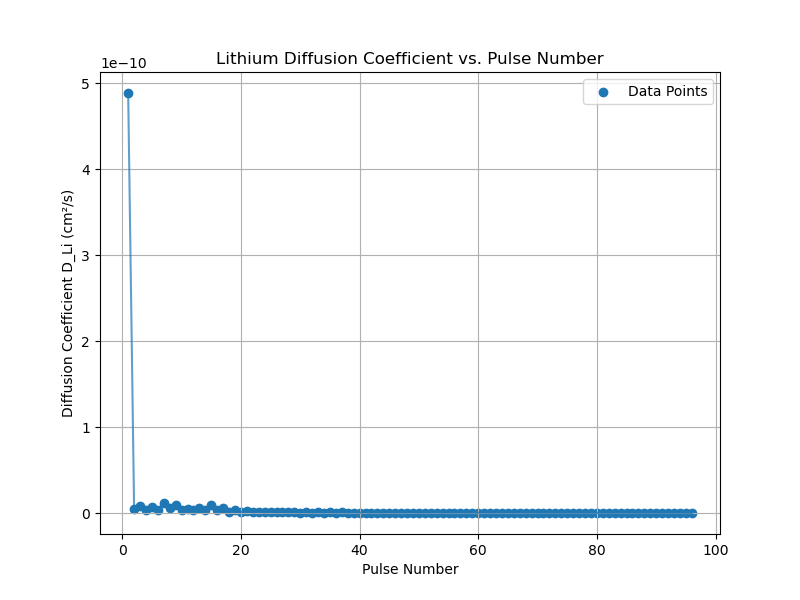

Lithium diffusion coefficients saved to GITT_Lithium_Diffusion_Coefficients.xlsx


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 📌 Step 1: Define Constants
L = 1e-5  # 100 nm in cm
sulfur_mass_mg = 1  # Sulfur weight in mg
sulfur_mass_g = sulfur_mass_mg / 1000  # Convert mg to g
pulse_duration = 600  # Fixed pulse duration in seconds (10 min)
current = 87.3e-6  # Current in Amperes (87.3 µA)



# 📌 Step 3: Apply Filters to Avoid Negative or Unrealistic Values
# Avoid near-zero ΔE_relax to prevent division errors
detection_results.loc[detection_results["ΔE_relax (V)"].abs() < 1e-4, "ΔE_relax (V)"] = np.nan

# Remove rows where essential values are NaN
detection_results.dropna(subset=["ΔE_corrected (V)", "ΔE_relax (V)"], inplace=True)

# 📌 Step 4: Compute D_Li Using the GITT Formula
# D_Li = (4/π) * (L² / τ) * (ΔE_corrected / ΔE_relax)²

detection_results["D_Li (cm²/s)"] = (
    (4 / np.pi) *
    ((L ** 2) / pulse_duration) *
    ((detection_results["ΔE_corrected (V)"] / detection_results["ΔE_relax (V)"]) ** 2)
)

# 📌 Step 7: Plot Pulse Number vs Diffusion Length
detection_results["Pulse Number"] = np.arange(1, len(detection_results) + 1)

# 📌 Step 2: Assign Capacity Based on Active Pulse Time
detection_results["Capacity (C)"] = detection_results['Pulse Number'] * pulse_duration * current  # Compute actual capacity
# 📌 Step 5: Normalize Capacity by Sulfur Mass
detection_results["Specific Capacity (mAh/g)"] = (detection_results["Capacity (C)"]) / sulfur_mass_g

# 📌 Step 6: Plot D_Li vs. Specific Capacity
plt.figure(figsize=(8, 6))
plt.scatter(detection_results["Capacity_ends (mAh/g)"], detection_results["D_Li (cm²/s)"], marker='o', label="Data Points")
plt.plot(detection_results["Capacity_ends (mAh/g)"], detection_results["D_Li (cm²/s)"], linestyle='-', alpha=0.7)
plt.xlabel("Specific Capacity (mAh/g)")
plt.ylabel("Diffusion Coefficient D_Li (cm²/s)")
plt.title("Lithium Diffusion Coefficient vs. Specific Capacity")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(detection_results["Pulse Number"], detection_results["D_Li (cm²/s)"], marker='o', label="Data Points")
plt.plot(detection_results["Pulse Number"], detection_results["D_Li (cm²/s)"], linestyle='-', alpha=0.7)
plt.xlabel("Pulse Number")
plt.ylabel("Diffusion Coefficient D_Li (cm²/s)")
plt.title("Lithium Diffusion Coefficient vs. Pulse Number")
plt.grid(True)
plt.legend()
plt.show()

# 📌 Step 8: Save Results to an Excel File
output_file = "GITT_Lithium_Diffusion_Coefficients.xlsx"
detection_results.to_excel(output_file, index=False)
print(f"Lithium diffusion coefficients saved to {output_file}")

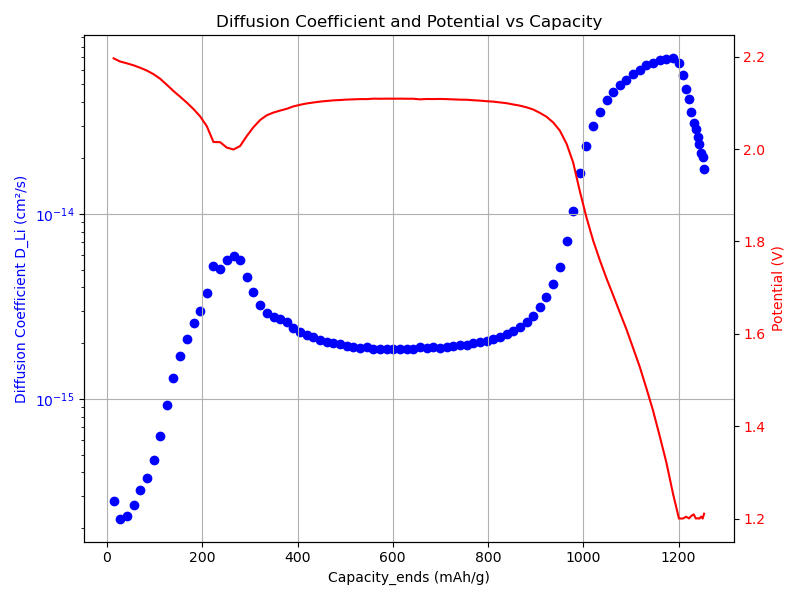

In [10]:
# 📌 Step 5: Plot Capacity vs Diffusion Coefficient with Overlaid Potential
detection_results["D_Li (cm²/s)"] = (
    (4 / np.pi) * ((L ** 2) / pulse_duration) * ((detection_results["Pulse End Voltage (V)"] - detection_results["Pulse Start Voltage (V)"]) ** 2)
)

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot Diffusion Coefficient
ax1.scatter(detection_results["Capacity_ends (mAh/g)"], detection_results["D_Li (cm²/s)"], color='b', label="D_Li (cm²/s)")
ax1.set_xlabel("Capacity_ends (mAh/g)")
ax1.set_ylabel("Diffusion Coefficient D_Li (cm²/s)", color='b')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True)

# Create a second y-axis for Potential
ax2 = ax1.twinx()
ax2.plot(detection_results["Capacity_ends (mAh/g)"], detection_results["Pulse End Voltage (V)"], color='r', linestyle='-', label="Potential (V)")
ax2.set_ylabel("Potential (V)", color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title("Diffusion Coefficient and Potential vs Capacity")
fig.tight_layout()
plt.show()


C:\Users\b1104371\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
C:\Users\b1104371\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
C:\Users\b1104371\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


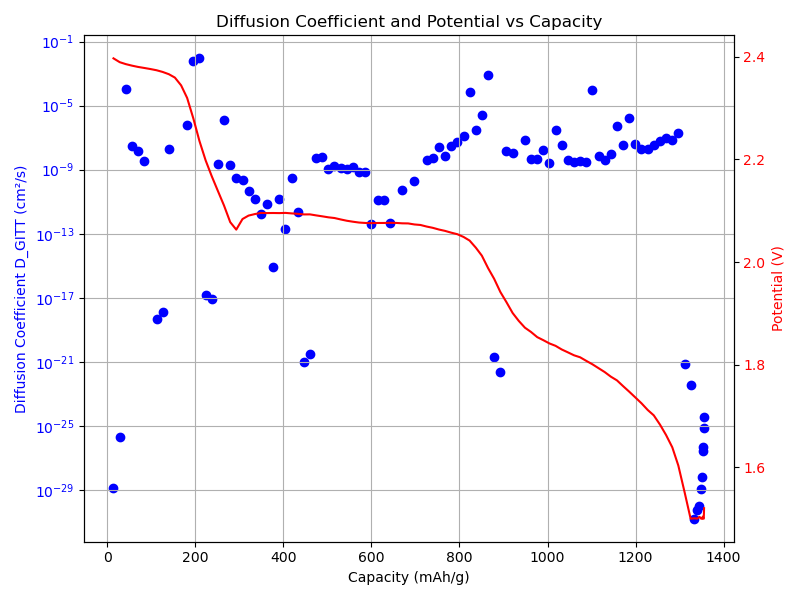

NameError: name 'new_output_file' is not defined

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 📌 Step 1: Define Constants
F = 96485  # Faraday constant (C/mol)
A = 0.5  # Electrode surface area (cm²)
V_M = 0.12  # Molar volume of sulfur in cm³/mol
Q_max = 1675  # Maximum capacity in mAh/g
pulse_duration = 600  # Fixed pulse duration in seconds (10 min)


# 📌 Step 3: Detect Key Points Using Current Transitions
pulse_starts = df.index[(df["Current/A"].shift(0) == 0) & (df["Current/A"].shift(-1) < 0)].tolist()
pulse_ends = df.index[(df["Current/A"].shift(0) < 0) & (df["Current/A"].shift(-1) == 0)].tolist()

# Detect Start of Relaxation (First Zero-Current Point After Pulse)
relax_starts = [i + 1 for i in pulse_ends if i + 1 < len(df)]

# Detect End of Relaxation (Last Zero-Current Point Before Next Pulse)
relax_ends = []
for start in pulse_starts[1:]:  # Ignore the first pulse for this
    relax_end_candidates = df.index[(df.index < start) & (df["Current/A"] == 0)].tolist()
    if relax_end_candidates:
        relax_ends.append(relax_end_candidates[-1])  # Take the last zero-current before the pulse

# Ensure all lists have the same length
min_length = min(len(pulse_starts), len(pulse_ends), len(relax_starts), len(relax_ends))
pulse_starts = pulse_starts[:min_length]
pulse_ends = pulse_ends[:min_length]
relax_starts = relax_starts[:min_length]
relax_ends = relax_ends[:min_length]

# 📌 Step 4: Create a DataFrame for Detected Points
detection_results = pd.DataFrame({
    "Pulse Start Time (s)": df.iloc[pulse_starts]["time/s"].values,
    "Pulse End Time (s)": df.iloc[pulse_ends]["time/s"].values,
    "Relaxation Start Time (s)": df.iloc[relax_starts]["time/s"].values,
    "Relaxation End Time (s)": df.iloc[relax_ends]["time/s"].values,
    "Pulse Start Voltage (V)": df.iloc[pulse_starts]["Ewe/V"].values,
    "Pulse End Voltage (V)": df.iloc[pulse_ends]["Ewe/V"].values,
    "Relaxation Start Voltage (V)": df.iloc[relax_starts]["Ewe/V"].values,
    "Relaxation End Voltage (V)": df.iloc[relax_ends]["Ewe/V"].values,
    "Capacity_ends (mAh/g)": df.iloc[pulse_ends]["Capacity/mA.h/g"].values,
    "Capacity_starts (mAh/g)": df.iloc[pulse_starts]["Capacity/mA.h/g"].values
})

# 📌 Step 5: Compute dE/d√t for Each Pulse
sqrt_t = np.sqrt(detection_results["Pulse End Time (s)"] - detection_results["Pulse Start Time (s)"])
detection_results["dE/dsqrt_t (V/s^0.5)"] = np.gradient(detection_results["Pulse End Voltage (V)"], sqrt_t)

# 📌 Step 6: Compute dE/dx (Composition Change Rate)
detection_results["dx"] = detection_results["Capacity_ends (mAh/g)"] - detection_results["Capacity_starts (mAh/g)"]
detection_results["dE/dx (V)"] = (detection_results["Pulse End Voltage (V)"] - detection_results["Pulse Start Voltage (V)"]) / detection_results["dx"]

# 📌 Step 7: Compute D_GITT Using the New Formula
detection_results["D_GITT (cm²/s)"] = (
    (4 / np.pi) * ((df["Current/A"].mean() * V_M) / (A * F)) *
    (detection_results["dE/dx (V)"] * detection_results["dE/dsqrt_t (V/s^0.5)"])
) ** 2

# 📌 Step 8: Plot Capacity vs Diffusion Coefficient with Overlaid Potential
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot Diffusion Coefficient
ax1.scatter(detection_results["Capacity_ends (mAh/g)"], detection_results["D_GITT (cm²/s)"], color='b', label="D_GITT (cm²/s)")
ax1.set_xlabel("Capacity (mAh/g)")
ax1.set_ylabel("Diffusion Coefficient D_GITT (cm²/s)", color='b')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True)

# Create a second y-axis for Potential
ax2 = ax1.twinx()
ax2.plot(detection_results["Capacity_ends (mAh/g)"], detection_results["Pulse End Voltage (V)"], color='r', linestyle='-', label="Potential (V)")
ax2.set_ylabel("Potential (V)", color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title("Diffusion Coefficient and Potential vs Capacity")
fig.tight_layout()
plt.show()

# 📌 Step 9: Save Results to Excel
output_file = "GITT_Diffusion_Coefficient_NewMethod.xlsx"
detection_results.to_excel(new_output_file, index=False)
print(f"Detection results saved to {output_file}")

# 📌 Step 10: Print Summary
print(f"Number of detected pulses: {len(pulse_starts)}")
print(f"Pulse Start Indices: {pulse_starts}")
print(f"Pulse End Indices: {pulse_ends}")
print(f"Relaxation Start Indices: {relax_starts}")
print(f"Relaxation End Indices: {relax_ends}")


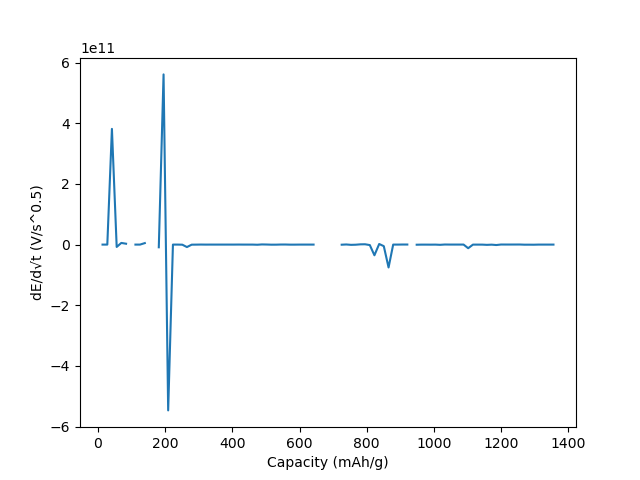

In [97]:
plt.figure()
plt.plot(detection_results["Capacity_ends (mAh/g)"], detection_results["dE/dsqrt_t (V/s^0.5)"])
plt.xlabel("Capacity (mAh/g)")
plt.ylabel("dE/d√t (V/s^0.5)")
plt.show()


In [98]:
print(detection_results[["Pulse Start Time (s)", "Pulse End Time (s)"]])


     Pulse Start Time (s)  Pulse End Time (s)
0                8.000000          595.000185
1             4210.000095         4805.000488
2             8400.048444         8995.000837
3            12610.000793        13205.001186
4            16800.049143        17395.001536
..                    ...                 ...
99          414411.590168       414521.823286
100         418112.012811       418186.824155
101         421774.582682       421839.556834
102         425434.746355       425480.512721
103         429075.702242       429110.512016

[104 rows x 2 columns]


In [ ]:
print(detection_results[["Pulse Start Voltage (V)", "Pulse End Voltage (V)"]])

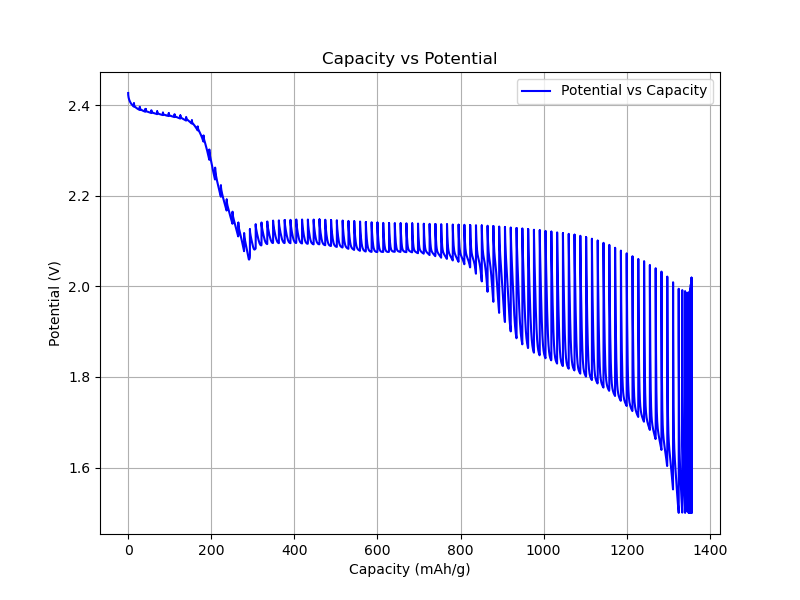

In [4]:
plt.figure(figsize=(8, 6))
plt.plot(df["Capacity/mA.h/g"], df["Ewe/V"], label="Potential vs Capacity", color='b')
plt.xlabel("Capacity (mAh/g)")
plt.ylabel("Potential (V)")
plt.title("Capacity vs Potential")
plt.grid(True)
plt.legend()
plt.show()

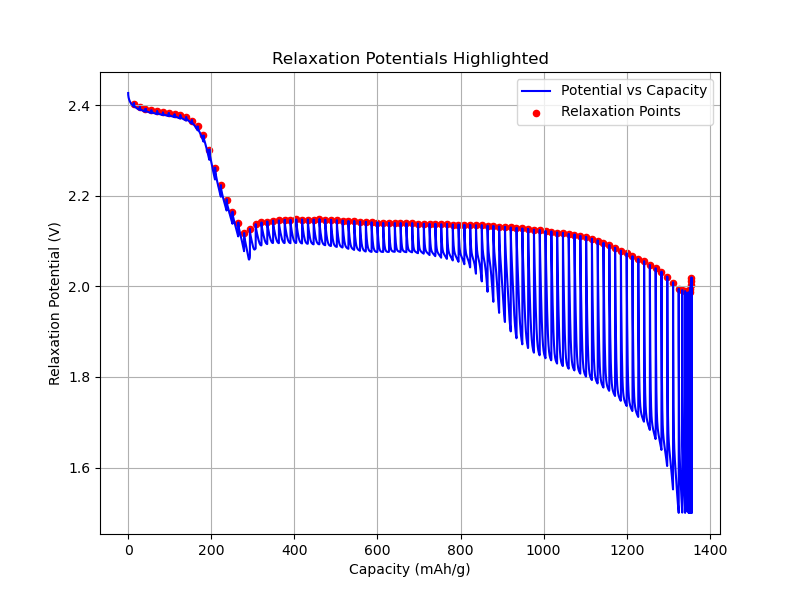

In [10]:
plt.figure(figsize=(8, 6))

# Plot the main data

plt.plot(df["Capacity/mA.h/g"], df["Ewe/V"], label="Potential vs Capacity", color='b')

# Highlight relaxation potentials with small spheres
plt.scatter(detection_results["Capacity_ends (mAh/g)"], detection_results["Relaxation End Voltage (V)"], color='r', s=20, label="Relaxation Points")

# Add labels, title, and legend
plt.xlabel("Capacity (mAh/g)")
plt.ylabel("Relaxation Potential (V)")
plt.title("Relaxation Potentials Highlighted")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Read the 'Charging Data' sheet from the Excel file
charging_data = pd.read_excel(file_path, sheet_name='Charging Data')

# Create the charging_df DataFrame
charging_df = charging_data.copy()

# Convert time from hours to seconds
charging_df["time/s"] = charging_df["time/h"] * 3600

# Convert Current to Amperes (if needed)
charging_df["Current/A"] = charging_df["<I>/mA"] / 1000  # Convert mA to A

print(charging_df.head())

       time/h    <I>/mA     Ewe/V  Capacity/mA.h/g         time/s  Current/A
0  120.615457  0.083667  2.325040         0.116171  434215.646413   0.000084
1  120.626569  0.083666  2.533000         1.045828  434255.647983   0.000084
2  120.637680  0.083665  2.485877         1.975478  434295.649553   0.000084
3  120.648792  0.083665  2.449614         2.905128  434335.651123   0.000084
4  120.659904  0.083666  2.432856         3.834780  434375.652693   0.000084


In [20]:
# Detect Key Points for Charging Using Current Transitions
charging_pulse_starts = charging_df.index[(charging_df["Current/A"].shift(0) == 0) & (charging_df["Current/A"].shift(-1) > 0)].tolist()
charging_pulse_ends = charging_df.index[(charging_df["Current/A"].shift(0) > 0) & (charging_df["Current/A"].shift(-1) == 0)].tolist()

# Detect Start of Relaxation (First Zero-Current Point After Charging Pulse)
charging_relax_starts = [i + 1 for i in charging_pulse_ends if i + 1 < len(charging_df)]

# Detect End of Relaxation (Last Zero-Current Point Before Next Charging Pulse)
charging_relax_ends = []
for start in charging_pulse_starts[1:]:  # Ignore the first pulse for this
    relax_end_candidates = charging_df.index[(charging_df.index < start) & (charging_df["Current/A"] == 0)].tolist()
    if relax_end_candidates:
        charging_relax_ends.append(relax_end_candidates[-1])  # Take the last zero-current before the pulse

# Ensure all lists have the same length
min_length_charging = min(len(charging_pulse_starts), len(charging_pulse_ends), len(charging_relax_starts), len(charging_relax_ends))
charging_pulse_starts = charging_pulse_starts[:min_length_charging]
charging_pulse_ends = charging_pulse_ends[:min_length_charging]
charging_relax_starts = charging_relax_starts[:min_length_charging]
charging_relax_ends = charging_relax_ends[:min_length_charging]

# Create a DataFrame for Detected Charging Points
charging_detection_results = pd.DataFrame({
    "Charging Pulse Start Time (s)": charging_df.iloc[charging_pulse_starts]["time/s"].values,
    "Charging Pulse End Time (s)": charging_df.iloc[charging_pulse_ends]["time/s"].values,
    "Charging Relaxation Start Time (s)": charging_df.iloc[charging_relax_starts]["time/s"].values,
    "Charging Relaxation End Time (s)": charging_df.iloc[charging_relax_ends]["time/s"].values,
    "Charging Pulse Start Voltage (V)": charging_df.iloc[charging_pulse_starts]["Ewe/V"].values,
    "Charging Pulse End Voltage (V)": charging_df.iloc[charging_pulse_ends]["Ewe/V"].values,
    "Charging Relaxation Start Voltage (V)": charging_df.iloc[charging_relax_starts]["Ewe/V"].values,
    "Charging Relaxation End Voltage (V)": charging_df.iloc[charging_relax_ends]["Ewe/V"].values,
    "Charging Capacity_ends (mAh/g)": charging_df.iloc[charging_pulse_ends]["Capacity/mA.h/g"].values,
    "Charging Capacity_starts (mAh/g)": charging_df.iloc[charging_pulse_starts]["Capacity/mA.h/g"].values,
})

# Save the charging detection results to an Excel file
charging_output_file = "GITT_charging_potential_detection.xlsx"
charging_detection_results.to_excel(charging_output_file, index=False)
print(f"Charging detection results saved to {charging_output_file}")

# Print Summary for Charging
print(f"Number of detected charging pulses: {len(charging_pulse_starts)}")
print(f"Charging Pulse Start Indices: {charging_pulse_starts}")
print(f"Charging Pulse End Indices: {charging_pulse_ends}")
print(f"Charging Relaxation Start Indices: {charging_relax_starts}")
print(f"Charging Relaxation End Indices: {charging_relax_ends}")

Charging detection results saved to GITT_charging_potential_detection.xlsx
Number of detected charging pulses: 149
Charging Pulse Start Indices: [104, 210, 315, 420, 525, 631, 736, 841, 946, 1052, 1157, 1262, 1367, 1473, 1578, 1683, 1788, 1894, 1999, 2104, 2209, 2315, 2420, 2525, 2630, 2736, 2841, 2946, 3051, 3157, 3262, 3367, 3472, 3578, 3683, 3788, 3893, 3999, 4104, 4209, 4314, 4420, 4525, 4630, 4735, 4841, 4946, 5051, 5156, 5262, 5367, 5472, 5577, 5683, 5788, 5893, 5998, 6104, 6209, 6314, 6419, 6525, 6630, 6735, 6840, 6946, 7051, 7156, 7261, 7367, 7472, 7577, 7682, 7788, 7893, 7998, 8103, 8209, 8314, 8419, 8524, 8630, 8735, 8840, 8945, 9051, 9156, 9261, 9366, 9472, 9577, 9682, 9787, 9893, 9998, 10103, 10208, 10313, 10415, 10515, 10614, 10713, 10811, 10908, 11005, 11102, 11198, 11294, 11390, 11485, 11580, 11675, 11770, 11865, 11960, 12054, 12148, 12242, 12336, 12430, 12524, 12617, 12711, 12804, 12897, 12991, 13084, 13177, 13270, 13363, 13455, 13548, 13641, 13733, 13826, 13918, 14010,

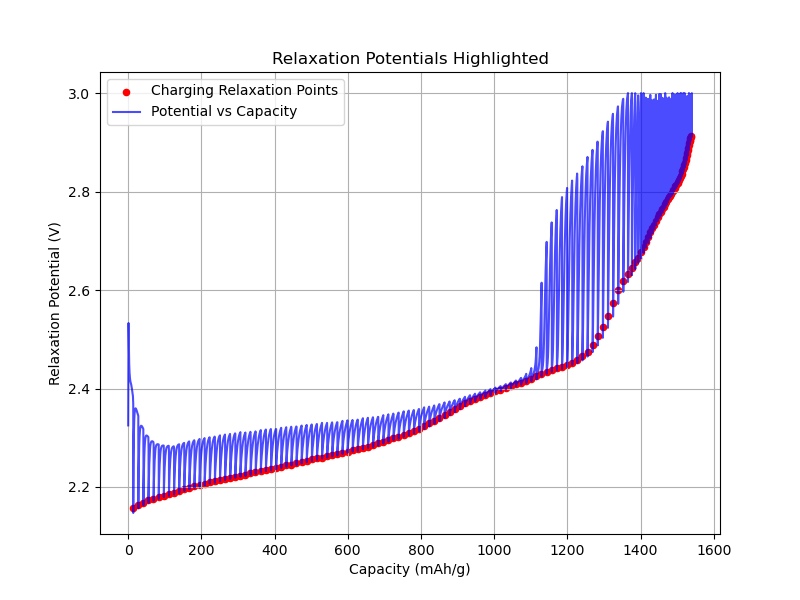

In [21]:
plt.figure(figsize=(8, 6))
# Highlight charging relaxation potentials without plotting the main data
plt.scatter(charging_detection_results["Charging Capacity_ends (mAh/g)"], 
            charging_detection_results["Charging Relaxation End Voltage (V)"], 
            color='r', s=20, label="Charging Relaxation Points"
)
plt.plot(charging_df["Capacity/mA.h/g"], charging_df["Ewe/V"], label="Potential vs Capacity", color='b', alpha=0.7)
# Highlight relaxation potentials with small sphere
# Add labels, title, and legend
plt.xlabel("Capacity (mAh/g)")
plt.ylabel("Relaxation Potential (V)")
plt.title("Relaxation Potentials Highlighted")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Create a DataFrame with discharging capacity and relaxation end potentials
discharging_data = detection_results[["Capacity_ends (mAh/g)", "Relaxation End Voltage (V)"]]

# Create a DataFrame with charging capacity and relaxation end potentials
charging_data_subset = charging_detection_results[["Charging Capacity_ends (mAh/g)", "Charging Relaxation End Voltage (V)"]]
charging_data_subset.columns = ["Capacity_ends (mAh/g)", "Relaxation End Voltage (V)"]  # Rename columns for consistency

# Combine discharging and charging data
combined_data = pd.concat([discharging_data, charging_data_subset], ignore_index=True)

# Save the combined data to an Excel file
combined_output_file = "combined_capacity_and_relaxation_end_potentials.xlsx"
combined_data.to_excel(combined_output_file, index=False)

print(f"Combined discharging and charging capacity and relaxation end potentials saved to {combined_output_file}")

Combined discharging and charging capacity and relaxation end potentials saved to combined_capacity_and_relaxation_end_potentials.xlsx
